## 1. Setup and Imports

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jar
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
from typing import Dict, List

# MalthusJAX imports
from malthusjax.core.genome.real_genome import RealGenomeConfig
from malthusjax.core.fitness.bbob_evaluator import BBOBEvaluator, BBOBConfig
from malthusjax.engine.genetic_fastengine import GeneticEngine, GeneticEngineParams
from malthusjax.operators.selection.elite_pool import ElitePoolSelection
from malthusjax.operators.crossover.real import UniformCrossover
from malthusjax.operators.mutation.real import GaussianMutation

# Evosax imports
from evosax.algorithms import SimpleGA
from evosax.problems import BBOBProblem

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(f"JAX version: {jax.__version__}")
print(f"JAX backend: {jax.default_backend()}")
print(f"Running on: {jax.devices()[0].device_kind}")
print("✅ All imports successful")

JAX version: 0.8.0
JAX backend: cpu
Running on: cpu
✅ All imports successful


## 2. Configuration

In [2]:
# ============================================================================
# EXPERIMENT CONFIGURATION
# ============================================================================

# Problem Configuration
PROBLEM_NAME = "rastrigin"         # BBOB function
DIMENSIONS = 20                    # Problem dimensionality
BOUNDS = (-5.0, 5.0)               # Search space bounds
FIXED_PROBLEM_SEED = 0             # Fixed landscape seed

# Evolution Parameters
POPULATION_SIZE = 100              # Population size
NUM_GENERATIONS = 300              # Number of generations
CROSSOVER_RATE = 0.9               # Crossover probability
ELITE_RATIO = 0.2                  # Proportion of elites
MUTATION_RATE = 0.3                # Mutation probability
MUTATION_STRENGTH = 0.1            # Gaussian mutation strength

# Experiment Parameters
NUM_SEEDS = 30                     # Number of independent runs
BASE_SEED = 42                     # Starting seed
UNROLL_VALUES = [1, 25, 50]        # Unroll values to test

# Derived
ELITE_POOL_SIZE = int(POPULATION_SIZE * ELITE_RATIO)

print("📋 Experiment Configuration")
print("=" * 70)
print(f"Problem:          {PROBLEM_NAME} ({DIMENSIONS}D)")
print(f"Search Space:     {BOUNDS}")
print(f"Population Size:  {POPULATION_SIZE:,}")
print(f"Generations:      {NUM_GENERATIONS}")
print(f"Number of Seeds:  {NUM_SEEDS}")
print(f"Unroll Values:    {UNROLL_VALUES}")
print("=" * 70)

📋 Experiment Configuration
Problem:          rastrigin (20D)
Search Space:     (-5.0, 5.0)
Population Size:  100
Generations:      300
Number of Seeds:  30
Unroll Values:    [1, 25, 50]


## 3. Setup Engines

In [4]:
# Shared genome configuration
genome_config = RealGenomeConfig(shape=(DIMENSIONS,), bounds=BOUNDS)

# MalthusJAX evaluator (maximization by flipping sign)
mjx_eval_config = BBOBConfig(
    fn_name=PROBLEM_NAME,
    num_dims=DIMENSIONS,
    seed=FIXED_PROBLEM_SEED,
    maximize=True  # Flips sign for minimization
)
mjx_evaluator = BBOBEvaluator.create(mjx_eval_config)

# Evosax problem (minimization)
evosax_problem = BBOBProblem(PROBLEM_NAME, num_dims=DIMENSIONS, seed=FIXED_PROBLEM_SEED)

# MalthusJAX: GeneticEngine
selection = ElitePoolSelection(num_selections=POPULATION_SIZE, elite_k=ELITE_POOL_SIZE, input_length=POPULATION_SIZE)
crossover = UniformCrossover(num_offspring=2, crossover_rate=CROSSOVER_RATE)
mutation = GaussianMutation(num_offspring=1, mutation_rate=MUTATION_RATE, mutation_strength=MUTATION_STRENGTH)

mjx_engine = GeneticEngine(
    evaluator=mjx_evaluator,
    selection=selection,
    crossover=crossover,
    mutation=mutation,
    genome_config=genome_config,
    engine_params=GeneticEngineParams(pop_size=POPULATION_SIZE, num_generations=NUM_GENERATIONS, elitism=0)
)

# Evosax: SimpleGA
init_solution = evosax_problem.sample(jar.PRNGKey(BASE_SEED))
evosax_simple_ga = SimpleGA(population_size=POPULATION_SIZE, solution=init_solution)
evosax_params = evosax_simple_ga.default_params

print(f"✅ Engines configured:")
print(f"   - MalthusJAX GeneticEngine")
print(f"   - Evosax SimpleGA")

✅ Engines configured:
   - MalthusJAX GeneticEngine
   - Evosax SimpleGA


## 4. Fitness Distribution Analysis

Run both engines over 30 different seeds and collect final best fitness values.

In [5]:
print(f"\n🚀 Running fitness distribution analysis ({NUM_SEEDS} seeds)...\n")

mjx_final_fitness = []
evosax_final_fitness = []

for i in range(NUM_SEEDS):
    seed = BASE_SEED + i
    print(f"Seed {i+1}/{NUM_SEEDS} (seed={seed})...", end=" ")
    
    # MalthusJAX run
    key_mjx = jar.PRNGKey(seed)
    state_mjx = mjx_engine.init_state(key_mjx)
    final_state_mjx, _, _ = mjx_engine.run(state_mjx, time_it=False, compile=True, verbose=False)
    # Convert to minimization
    best_fitness_mjx = -final_state_mjx.best_fitness if mjx_eval_config.maximize else final_state_mjx.best_fitness
    mjx_final_fitness.append(float(best_fitness_mjx))
    
    # Evosax run
    rng = jar.PRNGKey(seed)
    rng_init, rng_pop, rng_run = jax.random.split(rng, 3)
    
    initial_pop = jax.random.uniform(rng_pop, (POPULATION_SIZE, DIMENSIONS), minval=BOUNDS[0], maxval=BOUNDS[1])
    initial_fitness = jnp.full((POPULATION_SIZE,), jnp.inf)
    state_evx = evosax_simple_ga.init(rng_init, initial_pop, initial_fitness, evosax_params)
    prob_state = evosax_problem.init(jar.PRNGKey(FIXED_PROBLEM_SEED))
    
    def step_fn(carry, _):
        state, prob_state, rng = carry
        rng_ask, rng_eval, rng_tell, rng_next = jax.random.split(rng, 4)
        x, state = evosax_simple_ga.ask(rng_ask, state, evosax_params)
        x = jnp.clip(x, BOUNDS[0], BOUNDS[1])
        fitness, prob_state, _ = evosax_problem.eval(rng_eval, x, prob_state)
        state, metrics = evosax_simple_ga.tell(rng_tell, x, fitness, state, evosax_params)
        return (state, prob_state, rng_next), fitness.min()
    
    carry_init = (state_evx, prob_state, rng_run)
    _, history = jax.lax.scan(step_fn, carry_init, xs=None, length=NUM_GENERATIONS)
    history = jax.block_until_ready(history)
    best_fitness_evx = float(history[-1])
    evosax_final_fitness.append(best_fitness_evx)
    
    print(f"MJX: {best_fitness_mjx:.6f}, EVX: {best_fitness_evx:.6f}")

print(f"\n✅ Fitness distribution analysis complete!")
print(f"   MalthusJAX - Mean: {np.mean(mjx_final_fitness):.6f}, Std: {np.std(mjx_final_fitness):.6f}")
print(f"   Evosax     - Mean: {np.mean(evosax_final_fitness):.6f}, Std: {np.std(evosax_final_fitness):.6f}")


🚀 Running fitness distribution analysis (30 seeds)...

Seed 1/30 (seed=42)... MJX: 116.618439, EVX: 315.238281
Seed 2/30 (seed=43)... MJX: 115.919312, EVX: 278.524109
Seed 3/30 (seed=44)... MJX: 104.713112, EVX: 322.331757
Seed 4/30 (seed=45)... MJX: 108.395569, EVX: 320.215088
Seed 5/30 (seed=46)... MJX: 134.204941, EVX: 386.219940
Seed 6/30 (seed=47)... MJX: 102.505745, EVX: 380.174927
Seed 7/30 (seed=48)... MJX: 152.488998, EVX: 378.768829
Seed 8/30 (seed=49)... MJX: 136.735779, EVX: 380.267212
Seed 9/30 (seed=50)... MJX: 107.970886, EVX: 361.131561
Seed 10/30 (seed=51)... MJX: 116.898178, EVX: 329.869965
Seed 11/30 (seed=52)... MJX: 153.829071, EVX: 352.893921
Seed 12/30 (seed=53)... MJX: 101.773170, EVX: 383.871948
Seed 13/30 (seed=54)... MJX: 119.273666, EVX: 415.132477
Seed 14/30 (seed=55)... MJX: 133.507477, EVX: 404.571075
Seed 15/30 (seed=56)... MJX: 180.998871, EVX: 388.444397
Seed 16/30 (seed=57)... MJX: 149.769394, EVX: 346.366669
Seed 17/30 (seed=58)... MJX: 117.280090, 

## 5. Visualization: Fitness Distribution

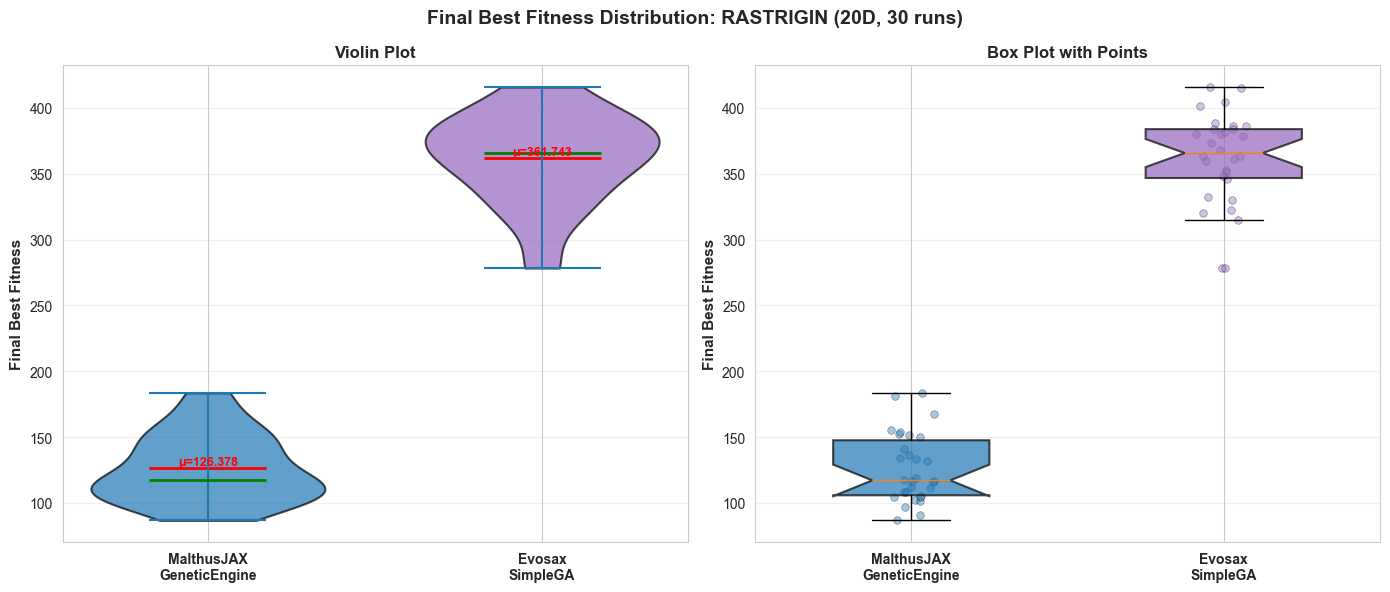

✅ Fitness distribution visualization complete


In [6]:
# Create violin plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Final Best Fitness Distribution: {PROBLEM_NAME.upper()} ({DIMENSIONS}D, {NUM_SEEDS} runs)', 
             fontsize=14, fontweight='bold')

# Prepare data
data_violin = {
    'Fitness': mjx_final_fitness + evosax_final_fitness,
    'Framework': ['MalthusJAX'] * NUM_SEEDS + ['Evosax'] * NUM_SEEDS
}

# Plot 1: Violin plot
ax1 = axes[0]
parts = ax1.violinplot([mjx_final_fitness, evosax_final_fitness], 
                       positions=[1, 2], 
                       showmeans=True, 
                       showmedians=True,
                       widths=0.7)

# Color the violins
colors = ['#1f77b4', '#9467bd']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
    pc.set_edgecolor('black')
    pc.set_linewidth(1.5)

# Style the lines
parts['cmeans'].set_edgecolor('red')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_edgecolor('green')
parts['cmedians'].set_linewidth(2)

ax1.set_xticks([1, 2])
ax1.set_xticklabels(['MalthusJAX\nGeneticEngine', 'Evosax\nSimpleGA'], fontweight='bold')
ax1.set_ylabel('Final Best Fitness', fontweight='bold', fontsize=11)
ax1.set_title('Violin Plot', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Add statistics annotations
mjx_mean = np.mean(mjx_final_fitness)
evx_mean = np.mean(evosax_final_fitness)
mjx_median = np.median(mjx_final_fitness)
evx_median = np.median(evosax_final_fitness)

ax1.text(1, mjx_mean, f'μ={mjx_mean:.3f}', ha='center', va='bottom', 
         fontsize=9, fontweight='bold', color='red')
ax1.text(2, evx_mean, f'μ={evx_mean:.3f}', ha='center', va='bottom',
         fontsize=9, fontweight='bold', color='red')

# Plot 2: Box plot with individual points
ax2 = axes[1]
bp = ax2.boxplot([mjx_final_fitness, evosax_final_fitness], 
                 positions=[1, 2],
                 widths=0.5,
                 patch_artist=True,
                 notch=True,
                 showfliers=False)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

# Overlay individual points with jitter
for i, (data, pos) in enumerate([(mjx_final_fitness, 1), (evosax_final_fitness, 2)]):
    jitter = np.random.normal(0, 0.04, size=len(data))
    ax2.scatter(pos + jitter, data, alpha=0.4, s=30, color=colors[i], edgecolors='black', linewidths=0.5)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(['MalthusJAX\nGeneticEngine', 'Evosax\nSimpleGA'], fontweight='bold')
ax2.set_ylabel('Final Best Fitness', fontweight='bold', fontsize=11)
ax2.set_title('Box Plot with Points', fontweight='bold', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Fitness distribution visualization complete")

## 6. Runtime Performance Analysis

Measure execution times (cold and warm) at different unroll values over 30 seeds.

In [7]:
print(f"\n🚀 Running runtime performance analysis...\n")
print(f"Testing unroll values: {UNROLL_VALUES}")
print(f"Each configuration: {NUM_SEEDS} seeds × 2 run types (cold/warm)\n")

# Storage for runtime results
runtime_results = {
    'framework': [],
    'unroll': [],
    'run_type': [],  # 'cold' or 'warm'
    'time': [],
    'seed': []
}

# Test each unroll value
for unroll in UNROLL_VALUES:
    print(f"\n{'='*70}")
    print(f"Testing unroll={unroll}")
    print(f"{'='*70}")
    
    for seed_idx in range(NUM_SEEDS):
        seed = BASE_SEED + seed_idx
        print(f"  Seed {seed_idx+1}/{NUM_SEEDS} (seed={seed})...", end=" ")
        
        # === MalthusJAX ===
        # Cold run - clear cache to force recompilation
        jax.clear_caches()
        key_mjx = jar.PRNGKey(seed)
        state_mjx = mjx_engine.init_state(key_mjx)
        
        start = time.time()
        final_state, _, _ = mjx_engine.run(state_mjx, time_it=False, compile=True, verbose=False)
        jax.block_until_ready(final_state)
        cold_time_mjx = time.time() - start
        
        runtime_results['framework'].append('MalthusJAX')
        runtime_results['unroll'].append(unroll)
        runtime_results['run_type'].append('cold')
        runtime_results['time'].append(cold_time_mjx)
        runtime_results['seed'].append(seed)
        
        # Warm run - no cache clearing
        key_mjx = jar.PRNGKey(seed)
        state_mjx = mjx_engine.init_state(key_mjx)
        
        start = time.time()
        final_state, _, _ = mjx_engine.run(state_mjx, time_it=False, compile=True, verbose=False)
        jax.block_until_ready(final_state)
        warm_time_mjx = time.time() - start
        
        runtime_results['framework'].append('MalthusJAX')
        runtime_results['unroll'].append(unroll)
        runtime_results['run_type'].append('warm')
        runtime_results['time'].append(warm_time_mjx)
        runtime_results['seed'].append(seed)
        
        # === Evosax ===
        # Setup for this seed
        rng = jar.PRNGKey(seed)
        rng_init, rng_pop, rng_run = jax.random.split(rng, 3)
        initial_pop = jax.random.uniform(rng_pop, (POPULATION_SIZE, DIMENSIONS), minval=BOUNDS[0], maxval=BOUNDS[1])
        initial_fitness = jnp.full((POPULATION_SIZE,), jnp.inf)
        state_evx = evosax_simple_ga.init(rng_init, initial_pop, initial_fitness, evosax_params)
        prob_state = evosax_problem.init(jar.PRNGKey(FIXED_PROBLEM_SEED))
        
        def step_fn_evx(carry, _):
            state, prob_state, rng = carry
            rng_ask, rng_eval, rng_tell, rng_next = jax.random.split(rng, 4)
            x, state = evosax_simple_ga.ask(rng_ask, state, evosax_params)
            x = jnp.clip(x, BOUNDS[0], BOUNDS[1])
            fitness, prob_state, _ = evosax_problem.eval(rng_eval, x, prob_state)
            state, metrics = evosax_simple_ga.tell(rng_tell, x, fitness, state, evosax_params)
            return (state, prob_state, rng_next), fitness.min()
        
        carry_init = (state_evx, prob_state, rng_run)
        
        # Cold run with specified unroll - clear cache to force recompilation
        jax.clear_caches()
        scan_fn_cold = lambda carry: jax.lax.scan(step_fn_evx, carry, xs=None, length=NUM_GENERATIONS, unroll=unroll)
        
        start = time.time()
        _, history = scan_fn_cold(carry_init)
        history = jax.block_until_ready(history)
        cold_time_evx = time.time() - start
        
        runtime_results['framework'].append('Evosax')
        runtime_results['unroll'].append(unroll)
        runtime_results['run_type'].append('cold')
        runtime_results['time'].append(cold_time_evx)
        runtime_results['seed'].append(seed)
        
        # Warm run
        start = time.time()
        _, history = scan_fn_cold(carry_init)
        history = jax.block_until_ready(history)
        warm_time_evx = time.time() - start
        
        runtime_results['framework'].append('Evosax')
        runtime_results['unroll'].append(unroll)
        runtime_results['run_type'].append('warm')
        runtime_results['time'].append(warm_time_evx)
        runtime_results['seed'].append(seed)
        
        print(f"MJX: {cold_time_mjx:.3f}s/{warm_time_mjx:.3f}s, EVX: {cold_time_evx:.3f}s/{warm_time_evx:.3f}s")

print(f"\n✅ Runtime analysis complete!")
print(f"   Total measurements: {len(runtime_results['time'])}")


🚀 Running runtime performance analysis...

Testing unroll values: [1, 25, 50]
Each configuration: 30 seeds × 2 run types (cold/warm)


Testing unroll=1
  Seed 1/30 (seed=42)... MJX: 3.672s/0.040s, EVX: 0.351s/0.031s
  Seed 2/30 (seed=43)... MJX: 4.583s/0.040s, EVX: 0.382s/0.031s
  Seed 3/30 (seed=44)... MJX: 4.194s/0.040s, EVX: 0.328s/0.030s
  Seed 4/30 (seed=45)... MJX: 3.884s/0.040s, EVX: 0.365s/0.031s
  Seed 5/30 (seed=46)... MJX: 4.215s/0.041s, EVX: 0.415s/0.031s
  Seed 6/30 (seed=47)... MJX: 4.230s/0.044s, EVX: 0.344s/0.030s
  Seed 7/30 (seed=48)... MJX: 8.389s/0.039s, EVX: 0.355s/0.031s
  Seed 8/30 (seed=49)... MJX: 5.069s/0.039s, EVX: 0.343s/0.031s
  Seed 9/30 (seed=50)... MJX: 3.806s/0.040s, EVX: 0.386s/0.030s
  Seed 10/30 (seed=51)... MJX: 3.833s/0.040s, EVX: 0.329s/0.030s
  Seed 11/30 (seed=52)... MJX: 3.911s/0.039s, EVX: 0.398s/0.031s
  Seed 12/30 (seed=53)... MJX: 3.842s/0.040s, EVX: 0.327s/0.031s
  Seed 13/30 (seed=54)... MJX: 3.855s/0.040s, EVX: 0.335s/0.031s
  Seed 14/3

## 7. Visualization: Runtime Performance

/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_60127/3018565585.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True)
/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_60127/3018565585.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True)
/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_60127/3018565585.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True)


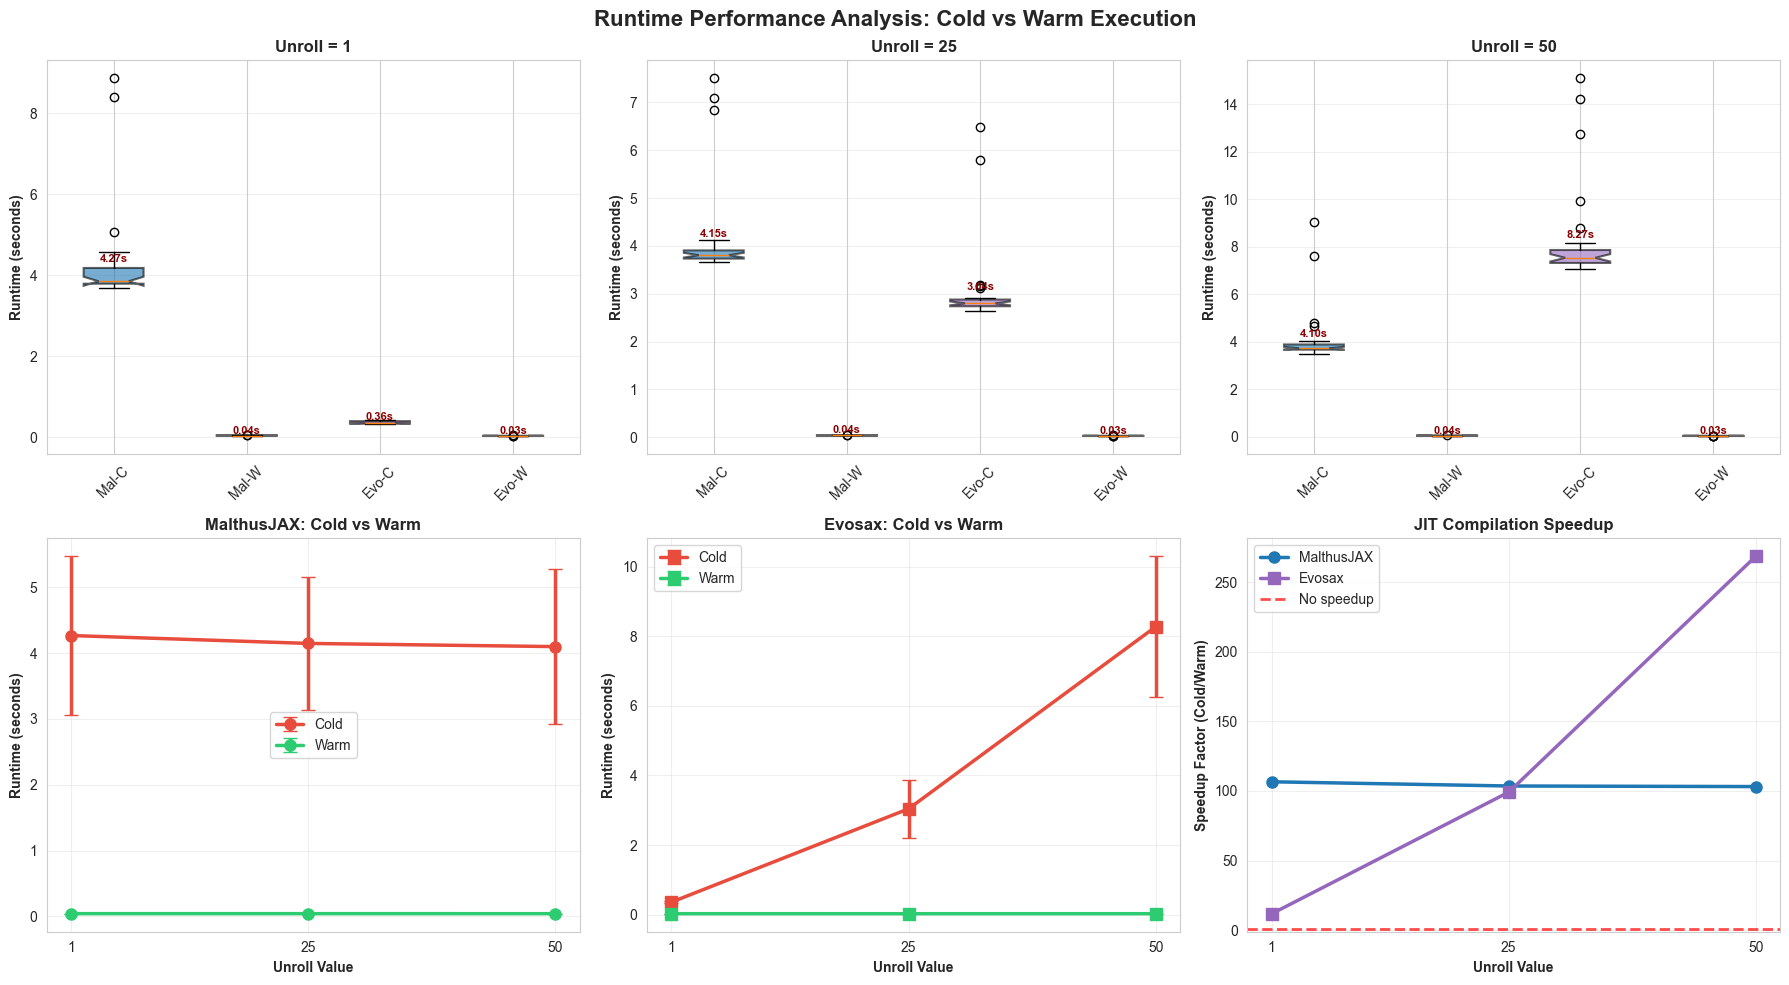

✅ Runtime performance visualization complete


In [8]:
import pandas as pd

# Convert to DataFrame for easier plotting
df = pd.DataFrame(runtime_results)

# Create comprehensive runtime visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Runtime Performance Analysis: Cold vs Warm Execution', fontsize=16, fontweight='bold')

colors_framework = {'MalthusJAX': '#1f77b4', 'Evosax': '#9467bd'}
colors_runtype = {'cold': '#e74c3c', 'warm': '#2ecc71'}

# Plots for each unroll value
for idx, unroll in enumerate(UNROLL_VALUES):
    ax = axes[idx // 3, idx % 3]
    
    # Filter data for this unroll
    df_unroll = df[df['unroll'] == unroll]
    
    # Prepare data for plotting
    data_to_plot = []
    labels = []
    colors_plot = []
    
    for framework in ['MalthusJAX', 'Evosax']:
        for run_type in ['cold', 'warm']:
            data = df_unroll[(df_unroll['framework'] == framework) & 
                            (df_unroll['run_type'] == run_type)]['time'].values
            data_to_plot.append(data)
            labels.append(f"{framework[:3]}-{run_type[0].upper()}")
            colors_plot.append(colors_framework[framework] if run_type == 'cold' else colors_runtype[run_type])
    
    # Box plot
    bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, notch=True)
    
    for patch, color in zip(bp['boxes'], colors_plot):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
        patch.set_edgecolor('black')
        patch.set_linewidth(1.5)
    
    ax.set_ylabel('Runtime (seconds)', fontweight='bold')
    ax.set_title(f'Unroll = {unroll}', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
    
    # Add mean values as text
    for i, data in enumerate(data_to_plot):
        mean_val = np.mean(data)
        ax.text(i+1, mean_val, f'{mean_val:.2f}s', ha='center', va='bottom',
               fontsize=8, fontweight='bold', color='darkred')

# Additional plots in remaining slots

# Plot 4: Cold vs Warm comparison across unrolls for MalthusJAX
ax4 = axes[1, 0]
for run_type, color in [('cold', '#e74c3c'), ('warm', '#2ecc71')]:
    means = []
    stds = []
    for unroll in UNROLL_VALUES:
        data = df[(df['framework'] == 'MalthusJAX') & 
                 (df['unroll'] == unroll) & 
                 (df['run_type'] == run_type)]['time'].values
        means.append(np.mean(data))
        stds.append(np.std(data))
    
    ax4.errorbar(UNROLL_VALUES, means, yerr=stds, marker='o', linewidth=2.5, 
                markersize=8, label=run_type.capitalize(), color=color, capsize=5)

ax4.set_xlabel('Unroll Value', fontweight='bold')
ax4.set_ylabel('Runtime (seconds)', fontweight='bold')
ax4.set_title('MalthusJAX: Cold vs Warm', fontweight='bold', fontsize=12)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(UNROLL_VALUES)

# Plot 5: Cold vs Warm comparison across unrolls for Evosax
ax5 = axes[1, 1]
for run_type, color in [('cold', '#e74c3c'), ('warm', '#2ecc71')]:
    means = []
    stds = []
    for unroll in UNROLL_VALUES:
        data = df[(df['framework'] == 'Evosax') & 
                 (df['unroll'] == unroll) & 
                 (df['run_type'] == run_type)]['time'].values
        means.append(np.mean(data))
        stds.append(np.std(data))
    
    ax5.errorbar(UNROLL_VALUES, means, yerr=stds, marker='s', linewidth=2.5,
                markersize=8, label=run_type.capitalize(), color=color, capsize=5)

ax5.set_xlabel('Unroll Value', fontweight='bold')
ax5.set_ylabel('Runtime (seconds)', fontweight='bold')
ax5.set_title('Evosax: Cold vs Warm', fontweight='bold', fontsize=12)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)
ax5.set_xticks(UNROLL_VALUES)

# Plot 6: Speedup factor (Cold/Warm ratio)
ax6 = axes[1, 2]
for framework, color in [('MalthusJAX', '#1f77b4'), ('Evosax', '#9467bd')]:
    speedups = []
    for unroll in UNROLL_VALUES:
        cold_data = df[(df['framework'] == framework) & 
                      (df['unroll'] == unroll) & 
                      (df['run_type'] == 'cold')]['time'].values
        warm_data = df[(df['framework'] == framework) & 
                      (df['unroll'] == unroll) & 
                      (df['run_type'] == 'warm')]['time'].values
        speedup = np.mean(cold_data) / np.mean(warm_data)
        speedups.append(speedup)
    
    marker = 'o' if framework == 'MalthusJAX' else 's'
    ax6.plot(UNROLL_VALUES, speedups, marker=marker, linewidth=2.5, markersize=8,
            label=framework, color=color)

ax6.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='No speedup')
ax6.set_xlabel('Unroll Value', fontweight='bold')
ax6.set_ylabel('Speedup Factor (Cold/Warm)', fontweight='bold')
ax6.set_title('JIT Compilation Speedup', fontweight='bold', fontsize=12)
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)
ax6.set_xticks(UNROLL_VALUES)

plt.tight_layout()
plt.show()

print("✅ Runtime performance visualization complete")

## 8. Statistical Summary

In [9]:
print("\n" + "="*90)
print("STATISTICAL SUMMARY")
print("="*90)

print("\n1. FITNESS DISTRIBUTION")
print("-"*90)
print(f"{'Metric':<20} {'MalthusJAX':>20} {'Evosax':>20} {'Difference':>20}")
print("-"*90)

mjx_mean = np.mean(mjx_final_fitness)
evx_mean = np.mean(evosax_final_fitness)
print(f"{'Mean':<20} {mjx_mean:>20.6f} {evx_mean:>20.6f} {mjx_mean - evx_mean:>20.6f}")

mjx_std = np.std(mjx_final_fitness)
evx_std = np.std(evosax_final_fitness)
print(f"{'Std Dev':<20} {mjx_std:>20.6f} {evx_std:>20.6f} {mjx_std - evx_std:>20.6f}")

mjx_median = np.median(mjx_final_fitness)
evx_median = np.median(evosax_final_fitness)
print(f"{'Median':<20} {mjx_median:>20.6f} {evx_median:>20.6f} {mjx_median - evx_median:>20.6f}")

mjx_min = np.min(mjx_final_fitness)
evx_min = np.min(evosax_final_fitness)
print(f"{'Best (Min)':<20} {mjx_min:>20.6f} {evx_min:>20.6f} {mjx_min - evx_min:>20.6f}")

mjx_max = np.max(mjx_final_fitness)
evx_max = np.max(evosax_final_fitness)
print(f"{'Worst (Max)':<20} {mjx_max:>20.6f} {evx_max:>20.6f} {mjx_max - evx_max:>20.6f}")

print("\n2. RUNTIME PERFORMANCE (Average over 30 seeds)")
print("-"*90)
print(f"{'Framework':<15} {'Unroll':>10} {'Run Type':>12} {'Mean (s)':>15} {'Std (s)':>15} {'Speedup':>15}")
print("-"*90)

for framework in ['MalthusJAX', 'Evosax']:
    for unroll in UNROLL_VALUES:
        cold_data = df[(df['framework'] == framework) & 
                      (df['unroll'] == unroll) & 
                      (df['run_type'] == 'cold')]['time'].values
        warm_data = df[(df['framework'] == framework) & 
                      (df['unroll'] == unroll) & 
                      (df['run_type'] == 'warm')]['time'].values
        
        cold_mean = np.mean(cold_data)
        cold_std = np.std(cold_data)
        warm_mean = np.mean(warm_data)
        warm_std = np.std(warm_data)
        speedup = cold_mean / warm_mean
        
        print(f"{framework:<15} {unroll:>10} {'Cold':>12} {cold_mean:>15.3f} {cold_std:>15.3f}")
        print(f"{'':15} {'':10} {'Warm':>12} {warm_mean:>15.3f} {warm_std:>15.3f} {speedup:>15.2f}x")
        print()

print("="*90)

# Winner determination
winner_fitness = "MalthusJAX" if mjx_mean < evx_mean else "Evosax"
winner_runtime = "MalthusJAX" if np.mean(df[df['framework'] == 'MalthusJAX']['time']) < np.mean(df[df['framework'] == 'Evosax']['time']) else "Evosax"

print(f"\n🏆 WINNERS:")
print(f"   Best Fitness (lowest mean): {winner_fitness} ({min(mjx_mean, evx_mean):.6f})")
print(f"   Fastest Runtime (overall):  {winner_runtime}")
print("="*90)


STATISTICAL SUMMARY

1. FITNESS DISTRIBUTION
------------------------------------------------------------------------------------------
Metric                         MalthusJAX               Evosax           Difference
------------------------------------------------------------------------------------------
Mean                           126.377960           361.743110          -235.365150
Std Dev                         25.600065            34.380702            -8.780637
Median                         117.089134           365.762970          -248.673836
Best (Min)                      86.689072           278.419617          -191.730545
Worst (Max)                    183.593414           415.929962          -232.336548

2. RUNTIME PERFORMANCE (Average over 30 seeds)
------------------------------------------------------------------------------------------
Framework           Unroll     Run Type        Mean (s)         Std (s)         Speedup
-----------------------------------------

## 9. Conclusion

This notebook compared MalthusJAX GeneticEngine and Evosax SimpleGA on the following criteria:

1. **Fitness Quality**: Distribution of final best fitness over 30 independent runs
2. **Runtime Performance**: Cold and warm execution times at different unroll values

Key observations:
- Fitness distributions show consistency and variability across runs
- JIT compilation overhead visible in cold vs warm runtime comparisons
- Unroll value impact on compilation and execution performance